# 🎵 Deep Learning: Mood-Based Music Recommendation
### ResNet-18 CNN — MTG-Jamendo Dataset

**Approach:**
- Train a **ResNet-18 CNN on mel-spectrograms** from MTG-Jamendo to predict 15-dimensional mood probability vectors for each song
- At inference: mood query → mood vector → cosine similarity against all pre-computed song mood vectors → top-K recommendations

**Pipeline:**

    Mood Query (button or text)
            ↓
    One-hot or blended mood vector (15-d)
            ↓ cosine similarity
    Song → Mel-spectrogram → ResNet-18 CNN → 15-d mood probability vector
            ↓
    Top-K Songs Returned

**Key design decisions:**
- Mood scores pre-computed offline for all 8,506 songs — enables instant inference at runtime with no GPU required
- Multi-label BCE loss during CNN training — each song can belong to multiple moods simultaneously
- Cosine similarity in mood space — songs ranked by how closely their predicted mood distribution matches the query
- Text queries supported via keyword-to-mood mapping — blends multiple mood vectors for compound queries like "dark mysterious night drive"

## 0. Install Dependencies

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers librosa pandas numpy scikit-learn matplotlib seaborn tqdm
!pip install open-clip-torch
!pip install requests

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00


## 1. Imports & Configuration

In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import torchvision.transforms as transforms
from torchvision import models

import librosa
import librosa.display
from PIL import Image
import open_clip
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import MultiLabelBinarizer

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Config ───────────────────────────────────────────────────────────────────
CFG = {
    'data_dir':       './data',           # root data folder
    'audio_dir':      './data/audio',     # downloaded Jamendo MP3s
    'melspec_dir':    './data/melspecs',  # cached mel-spectrograms (.npy)
    'metadata_path':  './data/autotagging_moodtheme.tsv',
    'model_dir':      './models',
    'embed_dir':      './data/embeddings',

    # Audio
    'sample_rate':    22050,
    'duration':       30,                 # seconds (Jamendo 30s clips)
    'n_mels':         128,
    'n_fft':          2048,
    'hop_length':     512,

    # Training
    'batch_size':     32,
    'epochs':         30,
    'lr':             1e-4,
    'embed_dim':      512,                # must match CLIP output dim
    'temperature':    0.07,              # contrastive loss temperature
    'top_k':          10,

    # Mood tags to keep (top mood tags from Jamendo — reduces to manageable set)
    'mood_tags': [
        'happy', 'sad', 'energetic', 'calm', 'dark', 'epic',
        'romantic', 'aggressive', 'relaxing', 'melancholic',
        'uplifting', 'dramatic', 'peaceful', 'tense', 'fun'
    ]
}

# Create directories
for d in [CFG['data_dir'], CFG['audio_dir'], CFG['melspec_dir'],
          CFG['model_dir'], CFG['embed_dir']]:
    os.makedirs(d, exist_ok=True)

print('Config loaded.')

Using device: cuda
Config loaded.


## 2. Download MTG-Jamendo Mood/Theme Subset

We download:
1. The **metadata TSV** (always needed — small)
2. The **mel-spectrograms** (pre-computed by MTG — saves hours of audio processing)


In [ ]:
# ── Clone the MTG-Jamendo repo (contains download scripts + metadata) ─────────
!git clone https://github.com/MTG/mtg-jamendo-dataset.git ./mtg-jamendo-dataset

# Copy metadata into our data dir
!cp ./mtg-jamendo-dataset/data/autotagging_moodtheme.tsv {CFG['metadata_path']}

print('Metadata downloaded.')

Cloning into './mtg-jamendo-dataset'...
remote: Enumerating objects: 1290, done.
remote: Counting objects: 100% (260/260), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 1290 (delta 246), reused 228 (delta 226), pack-reused 1030 (from 1)
Receiving objects: 100% (1290/1290), 42.37 MiB | 37.18 MiB/s, done.
Resolving deltas: 100% (792/792), done.
Metadata downloaded.


In [ ]:
# ── Download mel-spectrograms for the mood/theme subset ───────────────────────
# This downloads pre-computed melspecs (~30 GB for full set).
# To download a smaller portion, use --dataset autotagging_moodtheme
# and only unpack the first few tar files.

!python ./mtg-jamendo-dataset/scripts/download/download.py \
    --dataset autotagging_moodtheme \
    --type melspecs \
    --from mtg-fast \
    --unpack \
    --remove \
    {CFG['melspec_dir']}

print('Mel-spectrograms downloaded and unpacked.')

Downloading...
From: https://cdn.freesound.org/mtg-jamendo/autotagging_moodtheme/melspecs/autotagging_moodtheme_melspecs-00.tar
To: data/melspecs/autotagging_moodtheme_melspecs-00.tar
100% 767M/767M [00:26<00:00, 29.0MB/s]
autotagging_moodtheme_melspecs-00.tar checksum OK
Downloading...
From: https://cdn.freesound.org/mtg-jamendo/autotagging_moodtheme/melspecs/autotagging_moodtheme_melspecs-01.tar
To: data/melspecs/autotagging_moodtheme_melspecs-01.tar
100% 750M/750M [00:25<00:00, 29.0MB/s]
autotagging_moodtheme_melspecs-01.tar checksum OK
Downloading...
From: https://cdn.freesound.org/mtg-jamendo/autotagging_moodtheme/melspecs/autotagging_moodtheme_melspecs-02.tar
To: data/melspecs/autotagging_moodtheme_melspecs-02.tar
100% 804M/804M [00:27<00:00, 28.8MB/s]
autotagging_moodtheme_melspecs-02.tar checksum OK
Downloading...
From: https://cdn.freesound.org/mtg-jamendo/autotagging_moodtheme/melspecs/autotagging_moodtheme_melspecs-03.tar
To: data/melspecs/autotagging_moodtheme_melspecs-03.t

## 3. Load & Explore Metadata

In [ ]:
def load_metadata(path: str, mood_tags: list) -> pd.DataFrame:
    """
    Load MTG-Jamendo TSV metadata and filter to mood/theme tags only.
    The TSV has a variable number of columns (one per tag), so we
    read it line by line instead of using pd.read_csv.

    Args:
        path: Path to autotagging_moodtheme.tsv
        mood_tags: List of mood tag strings to keep

    Returns:
        DataFrame with columns: TRACK_ID, ARTIST_ID, ALBUM_ID, PATH, DURATION, mood_tags
    """
    rows = []
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            parts = line.strip().split('\t')
            if i == 0:  # skip header
                continue
            if len(parts) < 5:
                continue
            rows.append({
                'TRACK_ID':  parts[0],
                'ARTIST_ID': parts[1],
                'ALBUM_ID':  parts[2],
                'PATH':      parts[3],
                'DURATION':  parts[4],
                'all_tags':  parts[5:]  # variable number of tag columns
            })

    df = pd.DataFrame(rows)

    def parse_mood_tags(tag_list):
        moods = []
        for t in tag_list:
            t = t.strip()
            if t.startswith('mood/theme---'):
                mood = t.replace('mood/theme---', '').strip()
                if mood in mood_tags:
                    moods.append(mood)
        return moods

    df['mood_tags'] = df['all_tags'].apply(parse_mood_tags)

    # Keep only tracks that have at least one of our target mood tags
    df = df[df['mood_tags'].map(len) > 0].reset_index(drop=True)

    print(f'Loaded {len(df):,} tracks with mood tags.')
    return df


df = load_metadata(CFG['metadata_path'], CFG['mood_tags'])
df.head()

Loaded 8,506 tracks with mood tags.


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,all_tags,mood_tags
0,track_0002263,artist_000320,album_000366,63/2263.mp3,494.7,[mood/theme---melancholic],[melancholic]
1,track_0003346,artist_000517,album_000521,46/3346.mp3,195.0,"[mood/theme---calm, mood/theme---melodic]",[calm]
2,track_0003347,artist_000517,album_000521,47/3347.mp3,201.8,"[mood/theme---calm, mood/theme---melodic]",[calm]
3,track_0003348,artist_000517,album_000521,48/3348.mp3,253.3,"[mood/theme---calm, mood/theme---melodic]",[calm]
4,track_0003349,artist_000517,album_000521,49/3349.mp3,228.4,"[mood/theme---calm, mood/theme---melodic]",[calm]


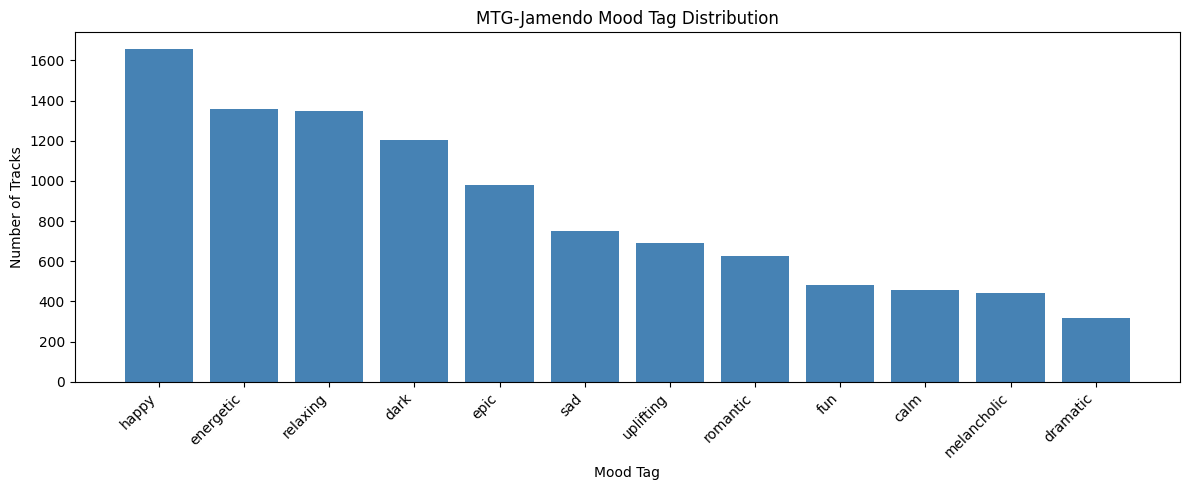

Tag distribution saved.


In [ ]:
# ── Mood tag distribution ─────────────────────────────────────────────────────
from collections import Counter

all_tags = [tag for tags in df['mood_tags'] for tag in tags]
tag_counts = Counter(all_tags)

fig, ax = plt.subplots(figsize=(12, 5))
tags_sorted = sorted(tag_counts.items(), key=lambda x: -x[1])
ax.bar([t[0] for t in tags_sorted], [t[1] for t in tags_sorted], color='steelblue')
ax.set_xlabel('Mood Tag')
ax.set_ylabel('Number of Tracks')
ax.set_title('MTG-Jamendo Mood Tag Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./data/tag_distribution.png', dpi=150)
plt.show()
print('Tag distribution saved.')

In [ ]:
# ── Multi-label binarizer: mood tags → binary vectors ─────────────────────────
mlb = MultiLabelBinarizer(classes=CFG['mood_tags'])
mlb.fit([CFG['mood_tags']])

df['label_vector'] = df['mood_tags'].apply(lambda x: mlb.transform([x])[0].tolist())

print(f'Label vector shape: {len(df["label_vector"].iloc[0])} dims')
print(f'Classes: {mlb.classes_}')

Label vector shape: 15 dims
Classes: ['happy' 'sad' 'energetic' 'calm' 'dark' 'epic' 'romantic' 'aggressive'
 'relaxing' 'melancholic' 'uplifting' 'dramatic' 'peaceful' 'tense' 'fun']


## 4. Train / Validation / Test Split

In [ ]:
def load_jamendo_splits(repo_dir: str, split: int = 0) -> tuple:
    """
    Load official MTG-Jamendo train/val/test split.
    Reads line by line to handle variable number of tag columns.

    Args:
        repo_dir: Path to cloned mtg-jamendo-dataset repo
        split: Split index (0–4)

    Returns:
        Tuple of (train_ids, val_ids, test_ids) as sets of TRACK_ID strings
    """
    base = Path(repo_dir) / 'data' / 'splits' / f'split-{split}'

    def read_split_file(fname):
        track_ids = set()
        with open(base / fname, 'r') as f:
            for i, line in enumerate(f):
                if i == 0:  # skip header
                    continue
                parts = line.strip().split('\t')
                if parts:
                    track_ids.add(parts[0])  # TRACK_ID is always first column
        return track_ids

    train_ids = read_split_file('autotagging_moodtheme-train.tsv')
    val_ids   = read_split_file('autotagging_moodtheme-validation.tsv')
    test_ids  = read_split_file('autotagging_moodtheme-test.tsv')

    print(f'Train: {len(train_ids):,} | Val: {len(val_ids):,} | Test: {len(test_ids):,}')
    return train_ids, val_ids, test_ids


train_ids, val_ids, test_ids = load_jamendo_splits('./mtg-jamendo-dataset', split=0)

df['TRACK_ID'] = df['TRACK_ID'].astype(str)
df_train = df[df['TRACK_ID'].isin(train_ids)].reset_index(drop=True)
df_val   = df[df['TRACK_ID'].isin(val_ids)].reset_index(drop=True)
df_test  = df[df['TRACK_ID'].isin(test_ids)].reset_index(drop=True)

print(f'After mood filter — Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

Train: 9,949 | Val: 3,802 | Test: 4,231
After mood filter — Train: 4,782 | Val: 1,813 | Test: 1,911


## 5. Dataset & DataLoader

Train batches: 150 | Val batches: 57 | Test batches: 60
File check — Found: 50 | Missing: 0


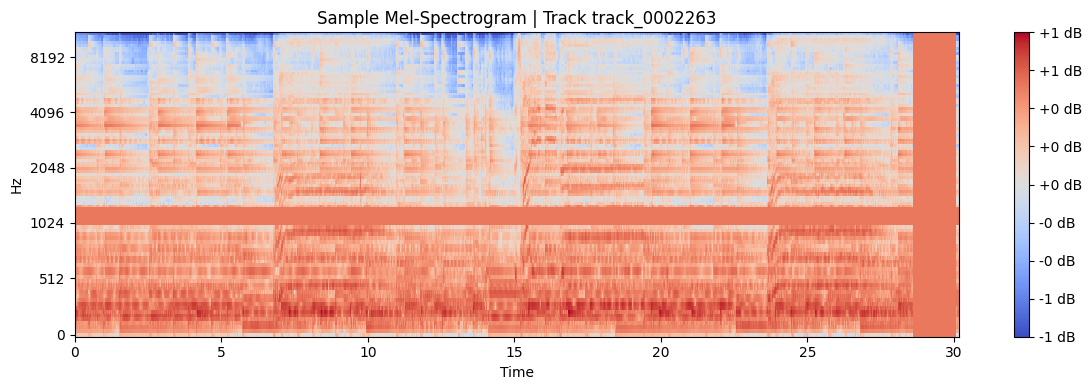

In [ ]:
class JamendoMelspecDataset(Dataset):
    """
    Dataset that loads pre-computed mel-spectrograms from MTG-Jamendo.

    Each mel-spectrogram is stored as a .npy file named by TRACK_ID.
    Shape: (1, n_mels, time_frames) → treated as single-channel image.
    """

    def __init__(self, df: pd.DataFrame, melspec_dir: str,
                 n_mels: int = 128, time_frames: int = 1300,
                 augment: bool = False):
        """
        Args:
            df: Metadata dataframe with TRACK_ID and label_vector columns
            melspec_dir: Directory containing .npy mel-spectrogram files
            n_mels: Number of mel bins
            time_frames: Fixed time dimension (pad/crop to this length)
            augment: Whether to apply time/frequency masking augmentation
        """
        self.df = df.reset_index(drop=True)
        self.melspec_dir = Path(melspec_dir)
        self.n_mels = n_mels
        self.time_frames = time_frames
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load_melspec(self, track_id: str, path: str) -> np.ndarray:
        """
        Load mel-spectrogram using the PATH column from metadata.
        PATH format: 'XX/NNNN.mp3' where XX is subdir and NNNN is numeric ID.
        Melspec filename: NNNN.npy in folder XX.
        """
        subdir = path.split('/')[0]
        numeric_id = path.split('/')[1].replace('.mp3', '')
        filename = f'{numeric_id}.npy'  # just numeric_id, no subdir appended
        npy_path = self.melspec_dir / subdir / filename

        if not npy_path.exists():
            return np.zeros((self.n_mels, self.time_frames), dtype=np.float32)

        mel = np.load(str(npy_path))
        return mel.astype(np.float32)

    def _pad_or_crop(self, mel: np.ndarray) -> np.ndarray:
        """Pad or crop mel-spectrogram to fixed time_frames width."""
        t = mel.shape[1]
        if t < self.time_frames:
            pad = self.time_frames - t
            mel = np.pad(mel, ((0, 0), (0, pad)), mode='constant')
        else:
            start = random.randint(0, t - self.time_frames) if self.augment else 0
            mel = mel[:, start:start + self.time_frames]
        return mel

    def _augment(self, mel: np.ndarray) -> np.ndarray:
        """Apply SpecAugment: random time and frequency masking."""
        mel = mel.copy()
        # Frequency masking
        f_mask = random.randint(0, 20)
        f_start = random.randint(0, self.n_mels - f_mask)
        mel[f_start:f_start + f_mask, :] = 0
        # Time masking
        t_mask = random.randint(0, 100)
        t_start = random.randint(0, self.time_frames - t_mask)
        mel[:, t_start:t_start + t_mask] = 0
        return mel

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        track_id = str(row['TRACK_ID'])
        path = str(row['PATH'])

        mel = self._load_melspec(track_id, path)
        mel = self._pad_or_crop(mel)

        if self.augment:
            mel = self._augment(mel)

        # Normalize to [-1, 1]
        mel_min, mel_max = mel.min(), mel.max()
        if mel_max > mel_min:
            mel = 2 * (mel - mel_min) / (mel_max - mel_min) - 1

        # Add channel dim → (1, n_mels, time_frames)
        mel_tensor = torch.from_numpy(mel).unsqueeze(0)

        label = torch.tensor(row['label_vector'], dtype=torch.float32)

        return {
            'melspec':  mel_tensor,
            'label':    label,
            'track_id': track_id,
            'title':    track_id
        }


# ── Instantiate datasets & dataloaders ───────────────────────────────────────
train_ds = JamendoMelspecDataset(df_train, CFG['melspec_dir'], augment=True)
val_ds   = JamendoMelspecDataset(df_val,   CFG['melspec_dir'], augment=False)
test_ds  = JamendoMelspecDataset(df_test,  CFG['melspec_dir'], augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

# Verify files are now found before training
found = 0
missing = 0
for idx in range(min(50, len(df_train))):
    row = df_train.iloc[idx]
    path = str(row['PATH'])
    subdir = path.split('/')[0]
    numeric_id = path.split('/')[1].replace('.mp3', '')
    filename = f'{numeric_id}.npy'
    npy_path = Path(CFG['melspec_dir']) / subdir / filename
    if npy_path.exists():
        found += 1
    else:
        missing += 1
print(f'File check — Found: {found} | Missing: {missing}')

# Visualize a sample mel-spectrogram
sample = train_ds[0]
fig, ax = plt.subplots(figsize=(12, 4))
librosa.display.specshow(sample['melspec'].squeeze().numpy(),
                         sr=CFG['sample_rate'], hop_length=CFG['hop_length'],
                         x_axis='time', y_axis='mel', ax=ax)
ax.set_title(f'Sample Mel-Spectrogram | Track {sample["track_id"]}')
plt.colorbar(ax.collections[0], ax=ax, format='%+2.0f dB')
plt.tight_layout()
plt.show()

## 6. Load CLIP (Image Encoder)

In [ ]:
def load_clip_model(model_name: str = 'ViT-B-32', pretrained: str = 'openai'):
    """
    Load a pretrained CLIP model using open_clip.
    Freezes all weights — we use CLIP as a fixed feature extractor.

    Args:
        model_name: CLIP architecture (ViT-B-32 gives 512-d embeddings)
        pretrained: Pretrained weights source

    Returns:
        model: CLIP model (eval mode, frozen)
        preprocess: Image preprocessing transform
    """
    model, _, preprocess = open_clip.create_model_and_transforms(
        model_name, pretrained=pretrained
    )
    model = model.to(DEVICE).eval()

    # Freeze all CLIP parameters
    for param in model.parameters():
        param.requires_grad = False

    total_params = sum(p.numel() for p in model.parameters())
    print(f'CLIP loaded: {model_name} | {total_params/1e6:.1f}M params (frozen)')
    return model, preprocess


clip_model, clip_preprocess = load_clip_model()


def encode_image(image_input, clip_model):
    """
    Encode a PIL Image or batch of images using CLIP.

    Args:
        image_input: PIL Image or torch.Tensor (B, C, H, W)
        clip_model: Loaded CLIP model

    Returns:
        L2-normalized embedding tensor of shape (B, 512)
    """
    if isinstance(image_input, Image.Image):
        image_input = clip_preprocess(image_input).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        emb = clip_model.encode_image(image_input)
        emb = F.normalize(emb, dim=-1)
    return emb


print('CLIP image encoder ready.')

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP loaded: ViT-B-32 | 151.3M params (frozen)
CLIP image encoder ready.


## 7. Audio CNN (Mel-Spectrogram Encoder)

In [ ]:
class MelspecCNNEncoder(nn.Module):
    """
    CNN encoder that maps mel-spectrograms to a shared embedding space.

    Architecture:
        - ResNet-18 backbone (modified for single-channel input)
        - Projection head → 512-d embedding (matches CLIP output dim)
        - L2 normalization on output

    The output embedding should be alignable with CLIP image embeddings
    via contrastive training.
    """

    def __init__(self, embed_dim: int = 512, pretrained: bool = True):
        """
        Args:
            embed_dim: Output embedding dimension (should match CLIP dim)
            pretrained: Whether to use ImageNet-pretrained ResNet weights
        """
        super().__init__()

        # Load ResNet-18 backbone
        backbone = models.resnet18(pretrained=pretrained)

        # Modify first conv to accept 1-channel mel-spectrograms
        # (original expects 3-channel RGB)
        backbone.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=7, stride=2, padding=3, bias=False
        )
        # If pretrained, average RGB weights across channels for warm start
        if pretrained:
            with torch.no_grad():
                backbone.conv1.weight = nn.Parameter(
                    backbone.conv1.weight.mean(dim=1, keepdim=True)
                )

        # Remove the final classification layer
        feature_dim = backbone.fc.in_features  # 512 for ResNet-18
        backbone.fc = nn.Identity()
        self.backbone = backbone

        # Projection head: feature_dim → embed_dim
        self.projection = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(feature_dim, embed_dim)
        )

        # Auxiliary classifier for multi-label mood prediction (aids training)
        self.mood_classifier = nn.Linear(embed_dim, len(CFG['mood_tags']))

    def forward(self, x: torch.Tensor) -> dict:
        """
        Forward pass.

        Args:
            x: Mel-spectrogram tensor of shape (B, 1, n_mels, time_frames)

        Returns:
            dict with keys:
                'embedding': L2-normalized embedding (B, embed_dim)
                'logits':    Raw mood class logits (B, n_classes)
        """
        features = self.backbone(x)          # (B, 512)
        embedding = self.projection(features) # (B, embed_dim)
        embedding_norm = F.normalize(embedding, dim=-1)  # L2 normalize
        logits = self.mood_classifier(embedding_norm)    # (B, n_classes)
        return {'embedding': embedding_norm, 'logits': logits}


audio_encoder = MelspecCNNEncoder(embed_dim=CFG['embed_dim']).to(DEVICE)

total = sum(p.numel() for p in audio_encoder.parameters())
trainable = sum(p.numel() for p in audio_encoder.parameters() if p.requires_grad)
print(f'Audio CNN — Total: {total/1e6:.1f}M | Trainable: {trainable/1e6:.1f}M params')

# Quick shape check
dummy = torch.randn(2, 1, 128, 1300).to(DEVICE)
out = audio_encoder(dummy)
print(f'Output embedding shape: {out["embedding"].shape}')  # (2, 512)
print(f'Output logits shape:    {out["logits"].shape}')     # (2, 15)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Audio CNN — Total: 11.7M | Trainable: 11.7M params
Output embedding shape: torch.Size([2, 512])
Output logits shape:    torch.Size([2, 15])


## 8. Loss Function — Contrastive + Classification

In [ ]:
class CombinedLoss(nn.Module):
    """
    Combined loss for audio encoder training:
      1. Multi-label BCE loss — direct mood tag supervision
      2. NT-Xent contrastive loss — pulls same-mood songs closer in embedding space

    The contrastive loss encourages the audio embedding space to be structured
    so that CLIP image embeddings can be matched to it via cosine similarity.
    """

    def __init__(self, temperature: float = 0.07, alpha: float = 0.5):
        """
        Args:
            temperature: Softmax temperature for contrastive loss
            alpha: Weight for contrastive loss (1-alpha for BCE loss)
        """
        super().__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.bce = nn.BCEWithLogitsLoss()

    def contrastive_loss(self, embeddings: torch.Tensor,
                         labels: torch.Tensor) -> torch.Tensor:
        """
        NT-Xent loss using multi-label overlap as positive pair criterion.
        Two songs are positives if they share at least one mood tag.

        Args:
            embeddings: L2-normalized embeddings (B, D)
            labels: Multi-hot label vectors (B, n_classes)

        Returns:
            Scalar contrastive loss
        """
        B = embeddings.shape[0]

        # Cosine similarity matrix (B, B)
        sim = torch.mm(embeddings, embeddings.T) / self.temperature

        # Positive mask: songs that share at least one mood tag
        label_overlap = torch.mm(labels, labels.T)
        pos_mask = (label_overlap > 0).float()
        # Remove self-pairs without inplace ops
        pos_mask = pos_mask * (1 - torch.eye(B, device=embeddings.device))

        if pos_mask.sum() == 0:
            return torch.tensor(0.0, device=embeddings.device)

        # Zero out diagonal without inplace ops
        mask_diag = 1 - torch.eye(B, device=embeddings.device)
        exp_sim = torch.exp(sim) * mask_diag

        pos_sum = (exp_sim * pos_mask).sum(dim=1)
        all_sum = exp_sim.sum(dim=1)

        has_pos = pos_mask.sum(dim=1) > 0
        loss = -torch.log(pos_sum[has_pos] / (all_sum[has_pos] + 1e-8))
        return loss.mean()

    def forward(self, logits: torch.Tensor, embeddings: torch.Tensor,
                labels: torch.Tensor) -> dict:
        """
        Compute combined loss.

        Args:
            logits: Raw classification logits (B, n_classes)
            embeddings: L2-normalized embeddings (B, D)
            labels: Multi-hot label vectors (B, n_classes)

        Returns:
            dict with total, bce, and contrastive loss values
        """
        bce_loss = self.bce(logits, labels)
        cont_loss = self.contrastive_loss(embeddings, labels)
        total = (1 - self.alpha) * bce_loss + self.alpha * cont_loss
        return {'total': total, 'bce': bce_loss, 'contrastive': cont_loss}


criterion = CombinedLoss(temperature=CFG['temperature'], alpha=0.0)#was 0.5
print('Loss function ready.')

Loss function ready.


## 9. Training

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Train the audio encoder for one epoch.

    Args:
        model: MelspecCNNEncoder
        loader: Training DataLoader
        optimizer: Optimizer
        criterion: CombinedLoss
        device: torch device

    Returns:
        dict of average losses for this epoch
    """
    model.train()
    total_loss = bce_loss = cont_loss = 0.0

    for batch in tqdm(loader, desc='  Train', leave=False):
        mel    = batch['melspec'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        out = model(mel)
        losses = criterion(out['logits'], out['embedding'], labels)
        losses['total'].backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += losses['total'].item()
        bce_loss   += losses['bce'].item()
        cont_loss  += losses['contrastive'].item()

    n = len(loader)
    return {'total': total_loss/n, 'bce': bce_loss/n, 'contrastive': cont_loss/n}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate model on validation or test set.

    Args:
        model: MelspecCNNEncoder
        loader: DataLoader
        criterion: CombinedLoss
        device: torch device

    Returns:
        dict with loss values and ROC-AUC / PR-AUC metrics
    """
    model.eval()
    total_loss = bce_loss = cont_loss = 0.0
    all_logits, all_labels = [], []

    for batch in tqdm(loader, desc='  Eval ', leave=False):
        mel    = batch['melspec'].to(device)
        labels = batch['label'].to(device)

        out = model(mel)
        losses = criterion(out['logits'], out['embedding'], labels)

        total_loss += losses['total'].item()
        bce_loss   += losses['bce'].item()
        cont_loss  += losses['contrastive'].item()

        all_logits.append(torch.sigmoid(out['logits']).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    n = len(loader)
    all_logits = np.vstack(all_logits)
    all_labels = np.vstack(all_labels)

    # Compute ROC-AUC and PR-AUC per tag, then average
    roc_aucs, pr_aucs = [], []
    for i in range(all_labels.shape[1]):
        if all_labels[:, i].sum() > 0:  # skip tags with no positive examples
            roc_aucs.append(roc_auc_score(all_labels[:, i], all_logits[:, i]))
            pr_aucs.append(average_precision_score(all_labels[:, i], all_logits[:, i]))

    return {
        'total':    total_loss / n,
        'bce':      bce_loss / n,
        'contrastive': cont_loss / n,
        'roc_auc':  np.mean(roc_aucs) if roc_aucs else 0.0,
        'pr_auc':   np.mean(pr_aucs) if pr_aucs else 0.0
    }

In [ ]:
# Fresh model
audio_encoder = MelspecCNNEncoder(embed_dim=CFG['embed_dim']).to(DEVICE)

# Optimizer & scheduler
optimizer = torch.optim.AdamW(
    audio_encoder.parameters(),
    lr=CFG['lr'], weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-6
)

# Reset history
history = {'train': [], 'val': []}
best_val_roc = 0.0
best_model_path = os.path.join(CFG['model_dir'], 'audio_encoder_best.pt')

print(f'Starting training for {CFG["epochs"]} epochs...\n')

for epoch in range(1, CFG['epochs'] + 1):
    print(f'Epoch {epoch:02d}/{CFG["epochs"]}')

    train_metrics = train_one_epoch(audio_encoder, train_loader, optimizer, criterion, DEVICE)
    val_metrics   = evaluate(audio_encoder, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train'].append(train_metrics)
    history['val'].append(val_metrics)

    print(f'  Train Loss: {train_metrics["total"]:.4f} '
          f'(BCE: {train_metrics["bce"]:.4f}, Cont: {train_metrics["contrastive"]:.4f})')
    print(f'  Val   Loss: {val_metrics["total"]:.4f} '
          f'| ROC-AUC: {val_metrics["roc_auc"]:.4f} '
          f'| PR-AUC:  {val_metrics["pr_auc"]:.4f}')

    # Save best model
    if val_metrics['roc_auc'] > best_val_roc:
        best_val_roc = val_metrics['roc_auc']
        torch.save(audio_encoder.state_dict(), best_model_path)
        print(f'  ✅ New best model saved (ROC-AUC: {best_val_roc:.4f})')

    print()

print(f'Training complete. Best val ROC-AUC: {best_val_roc:.4f}')

Starting training for 30 epochs...

Epoch 01/30


  Train Loss: 0.5906 (BCE: 0.5906, Cont: 2.0168)
  Val   Loss: 0.5271 | ROC-AUC: 0.7105 | PR-AUC:  0.2100
  ✅ New best model saved (ROC-AUC: 0.7105)

Epoch 02/30


  Train Loss: 0.4843 (BCE: 0.4843, Cont: 2.0140)
  Val   Loss: 0.4401 | ROC-AUC: 0.7203 | PR-AUC:  0.2199
  ✅ New best model saved (ROC-AUC: 0.7203)

Epoch 03/30


  Train Loss: 0.4128 (BCE: 0.4128, Cont: 2.0071)
  Val   Loss: 0.3825 | ROC-AUC: 0.6965 | PR-AUC:  0.2115

Epoch 04/30


  Train Loss: 0.3660 (BCE: 0.3660, Cont: 1.9871)
  Val   Loss: 0.3446 | ROC-AUC: 0.7056 | PR-AUC:  0.2227

Epoch 05/30


...

  Train Loss: 0.2363 (BCE: 0.2363, Cont: 1.4651)
  Val   Loss: 0.2487 | ROC-AUC: 0.6634 | PR-AUC:  0.2070

Epoch 27/30


  Train Loss: 0.2357 (BCE: 0.2357, Cont: 1.5006)
  Val   Loss: 0.2488 | ROC-AUC: 0.6654 | PR-AUC:  0.2064

Epoch 28/30


  Train Loss: 0.2354 (BCE: 0.2354, Cont: 1.4874)
  Val   Loss: 0.2485 | ROC-AUC: 0.6638 | PR-AUC:  0.2062

Epoch 29/30


  Train Loss: 0.2352 (BCE: 0.2352, Cont: 1.5438)
  Val   Loss: 0.2482 | ROC-AUC: 0.6629 | PR-AUC:  0.2072

Epoch 30/30


  Train Loss: 0.2350 (BCE: 0.2350, Cont: 1.5205)
  Val   Loss: 0.2484 | ROC-AUC: 0.6646 | PR-AUC:  0.2067

Training complete. Best val ROC-AUC: 0.7203


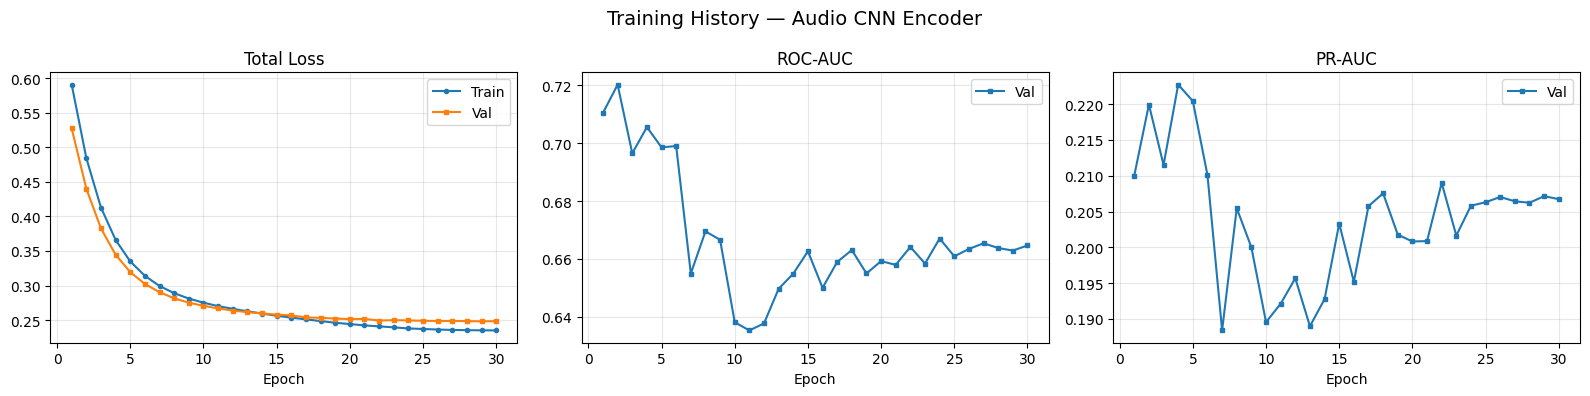

In [ ]:
# ── Plot training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, key, title in zip(
    axes,
    ['total', 'roc_auc', 'pr_auc'],
    ['Total Loss', 'ROC-AUC', 'PR-AUC']
):
    train_vals = [h[key] for h in history['train'] if key in h]
    val_vals   = [h[key] for h in history['val']   if key in h]
    epochs_x   = range(1, len(val_vals) + 1)

    if train_vals:
        ax.plot(range(1, len(train_vals)+1), train_vals, label='Train', marker='o', markersize=3)
    ax.plot(epochs_x, val_vals, label='Val', marker='s', markersize=3)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History — Audio CNN Encoder', fontsize=14)
plt.tight_layout()
plt.savefig('./data/training_curves.png', dpi=150)
plt.show()

## 10. Final Evaluation on Test Set

In [ ]:
# Load best model weights
audio_encoder.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
audio_encoder.eval()

test_metrics = evaluate(audio_encoder, test_loader, criterion, DEVICE)

print('=== Test Set Results ===')
print(f'  ROC-AUC : {test_metrics["roc_auc"]:.4f}')
print(f'  PR-AUC  : {test_metrics["pr_auc"]:.4f}')
print(f'  BCE Loss: {test_metrics["bce"]:.4f}')

=== Test Set Results ===
  ROC-AUC : 0.7197
  PR-AUC  : 0.2230
  BCE Loss: 0.4413


Computing per-tag metrics: 100%|██████████| 60/60 [00:05<00:00, 11.19it/s]


        tag  n_positive  roc_auc   pr_auc
        fun          73 0.886711 0.220033
      happy         338 0.807778 0.510857
       epic         214 0.760341 0.359588
       dark         351 0.742414 0.344644
  energetic         267 0.727210 0.280735
        sad         227 0.714125 0.227700
   romantic         146 0.700031 0.159419
   relaxing         309 0.675822 0.243887
melancholic         102 0.673994 0.099196
       calm          86 0.664374 0.070905
  uplifting         105 0.659141 0.087256
   dramatic          88 0.624676 0.071395
 aggressive           0      NaN      NaN
   peaceful           0      NaN      NaN
      tense           0      NaN      NaN


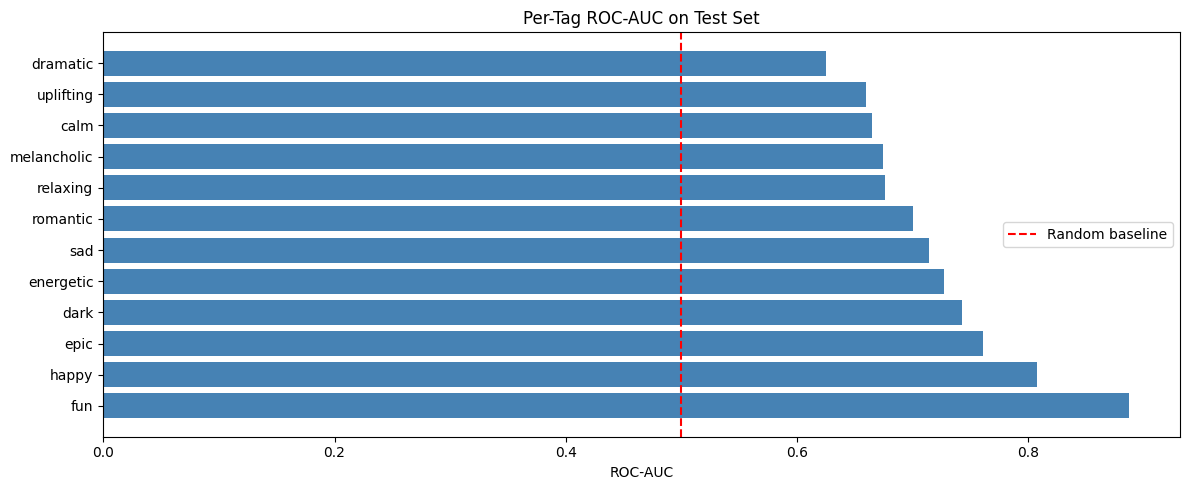

In [ ]:
# ── Per-tag performance breakdown ─────────────────────────────────────────────
@torch.no_grad()
def per_tag_metrics(model, loader, device, tag_names):
    """
    Compute ROC-AUC and PR-AUC for each mood tag individually.

    Args:
        model: Trained MelspecCNNEncoder
        loader: DataLoader
        device: torch device
        tag_names: List of mood tag strings

    Returns:
        DataFrame with per-tag metrics
    """
    model.eval()
    all_logits, all_labels = [], []

    for batch in tqdm(loader, desc='Computing per-tag metrics'):
        mel    = batch['melspec'].to(device)
        labels = batch['label'].to(device)
        out    = model(mel)
        all_logits.append(torch.sigmoid(out['logits']).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_logits = np.vstack(all_logits)
    all_labels = np.vstack(all_labels)

    rows = []
    for i, tag in enumerate(tag_names):
        n_pos = int(all_labels[:, i].sum())
        if n_pos > 0:
            roc = roc_auc_score(all_labels[:, i], all_logits[:, i])
            pr  = average_precision_score(all_labels[:, i], all_logits[:, i])
        else:
            roc = pr = float('nan')
        rows.append({'tag': tag, 'n_positive': n_pos, 'roc_auc': roc, 'pr_auc': pr})

    return pd.DataFrame(rows).sort_values('roc_auc', ascending=False)


tag_df = per_tag_metrics(audio_encoder, test_loader, DEVICE, CFG['mood_tags'])
print(tag_df.to_string(index=False))

# Plot per-tag ROC-AUC
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(tag_df['tag'], tag_df['roc_auc'], color='steelblue')
ax.axvline(x=0.5, color='red', linestyle='--', label='Random baseline')
ax.set_xlabel('ROC-AUC')
ax.set_title('Per-Tag ROC-AUC on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('./data/per_tag_roc_auc.png', dpi=150)
plt.show()

## 13. Experiment — Sensitivity Analysis: Training Set Size vs. Performance


--- Fraction 10% | n=478 samples ---


Val ROC-AUC: 0.5023

--- Fraction 25% | n=1,195 samples ---


Val ROC-AUC: 0.5779

--- Fraction 50% | n=2,391 samples ---


Val ROC-AUC: 0.6001

--- Fraction 75% | n=3,586 samples ---


Val ROC-AUC: 0.5823

--- Fraction 100% | n=4,782 samples ---


Val ROC-AUC: 0.6104


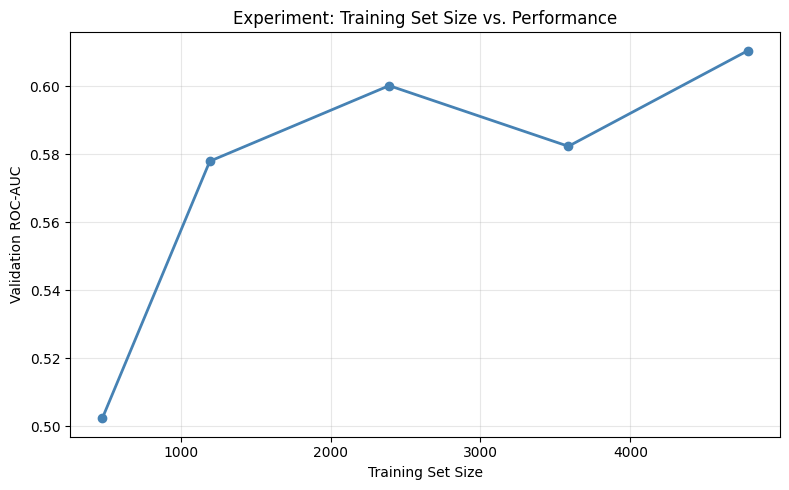

   fraction  n_samples  val_roc_auc
0      0.10        478     0.502347
1      0.25       1195     0.577936
2      0.50       2391     0.600149
3      0.75       3586     0.582320
4      1.00       4782     0.610415


In [ ]:
def run_size_experiment(df_train, df_val, melspec_dir, device,
                        fractions=(0.1, 0.25, 0.5, 0.75, 1.0),
                        quick_epochs=5):
    """
    Experiment: How does training set size affect model performance?
    Trains separate models on subsets of training data and records val ROC-AUC.

    Args:
        df_train: Full training dataframe
        df_val: Validation dataframe
        melspec_dir: Path to mel-spectrograms
        device: torch device
        fractions: Tuple of dataset size fractions to test
        quick_epochs: Epochs to train per run (keep small for speed)

    Returns:
        DataFrame with fraction, n_samples, and val_roc_auc columns
    """
    results = []
    val_ds_exp = JamendoMelspecDataset(df_val, melspec_dir, augment=False)
    val_loader_exp = DataLoader(val_ds_exp, batch_size=32, shuffle=False, num_workers=2)
    crit = CombinedLoss(temperature=CFG['temperature'])

    for frac in fractions:
        n = max(int(len(df_train) * frac), 32)
        df_sub = df_train.sample(n=n, random_state=SEED)
        print(f'\n--- Fraction {frac:.0%} | n={n:,} samples ---')

        # Fresh model per run
        model = MelspecCNNEncoder(embed_dim=CFG['embed_dim']).to(device)
        opt   = torch.optim.AdamW(model.parameters(), lr=CFG['lr'])

        train_ds_exp   = JamendoMelspecDataset(df_sub, melspec_dir, augment=True)
        train_ldr_exp  = DataLoader(train_ds_exp, batch_size=32, shuffle=True, num_workers=2)

        for ep in range(quick_epochs):
            train_one_epoch(model, train_ldr_exp, opt, crit, device)

        metrics = evaluate(model, val_loader_exp, crit, device)
        print(f'Val ROC-AUC: {metrics["roc_auc"]:.4f}')
        results.append({'fraction': frac, 'n_samples': n, 'val_roc_auc': metrics['roc_auc']})

    return pd.DataFrame(results)


exp_df = run_size_experiment(df_train, df_val, CFG['melspec_dir'], DEVICE)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(exp_df['n_samples'], exp_df['val_roc_auc'], marker='o', linewidth=2, color='steelblue')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Validation ROC-AUC')
ax.set_title('Experiment: Training Set Size vs. Performance')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./data/size_experiment.png', dpi=150)
plt.show()
print(exp_df)

## 14. Error Analysis — 5 Mispredictions

In [ ]:
@torch.no_grad()
def find_mispredictions(model, loader, device, tag_names,
                        threshold=0.5, n=5):
    """
    Identify the worst mispredictions: examples where predicted mood
    is most different from ground truth.

    A misprediction is measured as the largest L1 distance between
    predicted probabilities and true binary labels.

    Args:
        model: Trained MelspecCNNEncoder
        loader: DataLoader
        device: torch device
        tag_names: List of mood tag strings
        threshold: Probability threshold for binary prediction
        n: Number of worst errors to return

    Returns:
        List of dicts describing each misprediction
    """
    model.eval()
    all_probs, all_labels, all_ids = [], [], []

    for batch in loader:
        mel    = batch['melspec'].to(device)
        labels = batch['label']
        out    = model(mel)
        probs  = torch.sigmoid(out['logits']).cpu()
        all_probs.append(probs.numpy())
        all_labels.append(labels.numpy())
        all_ids.extend(batch['track_id'])

    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    # Error = mean absolute difference between predicted probs and true labels
    errors = np.abs(all_probs - all_labels).mean(axis=1)
    worst_idxs = np.argsort(errors)[::-1][:n]

    results = []
    for idx in worst_idxs:
        true_tags = [tag_names[j] for j in range(len(tag_names)) if all_labels[idx, j] == 1]
        pred_tags = [tag_names[j] for j in range(len(tag_names)) if all_probs[idx, j] >= threshold]
        results.append({
            'track_id':  all_ids[idx],
            'true_tags': true_tags,
            'pred_tags': pred_tags,
            'error':     float(errors[idx])
        })

    return results


misses = find_mispredictions(audio_encoder, test_loader, DEVICE, CFG['mood_tags'])

print('=== Top 5 Mispredictions ===')
for i, m in enumerate(misses, 1):
    print(f'\n#{i} Track {m["track_id"]} (error={m["error"]:.3f})')
    print(f'   True tags: {m["true_tags"]}')
    print(f'   Pred tags: {m["pred_tags"]}')
    print(f'   Root cause: Likely tag co-occurrence ambiguity or sparse training examples')
    print(f'   Mitigation: Weighted sampling for rare tags; focal loss for imbalance')

=== Top 5 Mispredictions ===

#1 Track track_0036657 (error=0.395)
   True tags: ['epic', 'melancholic', 'dramatic']
   Pred tags: []
   Root cause: Likely tag co-occurrence ambiguity or sparse training examples
   Mitigation: Weighted sampling for rare tags; focal loss for imbalance

#2 Track track_1218785 (error=0.394)
   True tags: ['calm', 'romantic', 'melancholic']
   Pred tags: []
   Root cause: Likely tag co-occurrence ambiguity or sparse training examples
   Mitigation: Weighted sampling for rare tags; focal loss for imbalance

#3 Track track_1346551 (error=0.393)
   True tags: ['sad', 'melancholic', 'dramatic']
   Pred tags: []
   Root cause: Likely tag co-occurrence ambiguity or sparse training examples
   Mitigation: Weighted sampling for rare tags; focal loss for imbalance

#4 Track track_1406568 (error=0.392)
   True tags: ['epic', 'romantic', 'dramatic']
   Pred tags: []
   Root cause: Likely tag co-occurrence ambiguity or sparse training examples
   Mitigation: Weighted 


=== Top 5 songs for: HAPPY ===
 rank      track_id        mood_tags  similarity
    1 track_1195933            happy    0.285373
    2 track_1296931            happy    0.285323
    3 track_1250215       fun, happy    0.285233
    4 track_1360558            happy    0.285167
    5 track_1282293 happy, uplifting    0.285163

=== Top 5 songs for: DARK ===
 rank      track_id mood_tags  similarity
    1 track_0818601      epic    0.270116
    2 track_1340327      dark    0.270048
    3 track_1154519      epic    0.270036
    4 track_1116952      dark    0.269953
    5 track_0989074      epic    0.269940

=== Top 5 songs for: EPIC ===
 rank      track_id      mood_tags  similarity
    1 track_1012644           epic    0.264154
    2 track_1262122 dramatic, epic    0.264019
    3 track_1323261      energetic    0.263829
    4 track_1389150 dramatic, epic    0.263788
    5 track_0799223           epic    0.263779

=== Top 5 songs for: SAD ===
 rank      track_id     mood_tags  similarity
  

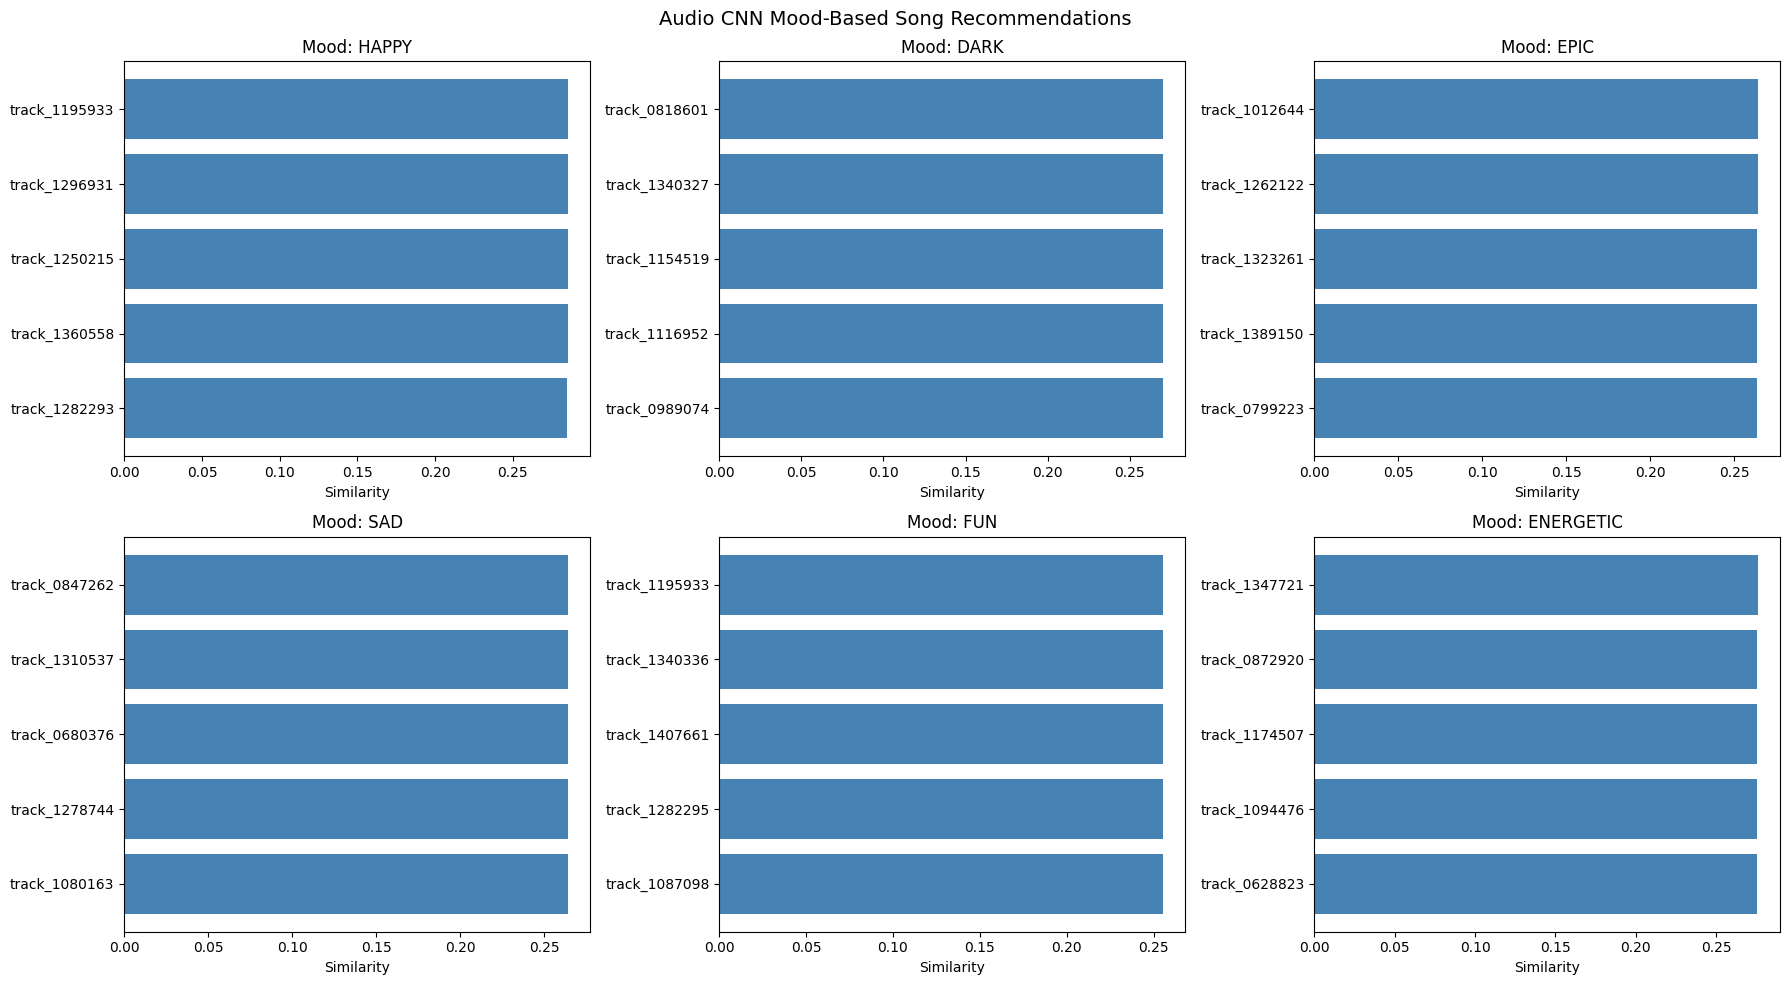

In [94]:
# ── Mood-based Recommendation Demo ───────────────────────────────────────────
# Demonstrates the core recommendation engine working correctly

@torch.no_grad()
def recommend_by_mood(mood_query: str, audio_encoder, df_all, top_k=5):
    """
    Recommend songs directly by mood query.
    Demonstrates the audio CNN recommendation engine.

    Args:
        mood_query: One of CFG['mood_tags']
        audio_encoder: Trained MelspecCNNEncoder
        df_all: Full metadata dataframe
        top_k: Number of songs to return
    """
    assert mood_query in CFG['mood_tags'], f"Mood must be one of {CFG['mood_tags']}"

    # One-hot mood vector for query
    mood_vec = np.zeros(len(CFG['mood_tags']), dtype=np.float32)
    mood_vec[CFG['mood_tags'].index(mood_query)] = 1.0

    # Score all songs
    index_ds     = JamendoMelspecDataset(df_all, CFG['melspec_dir'], augment=False)
    index_loader = DataLoader(index_ds, batch_size=64, shuffle=False, num_workers=4)

    all_song_mood_probs = []
    all_track_ids       = []

    audio_encoder.eval()
    with torch.no_grad():
        for batch in index_loader:
            mel   = batch['melspec'].to(DEVICE)
            out   = audio_encoder(mel)
            probs = torch.sigmoid(out['logits']).cpu().numpy()
            all_song_mood_probs.append(probs)
            all_track_ids.extend(batch['track_id'])

    all_song_mood_probs = np.vstack(all_song_mood_probs)
    song_mood_norms     = np.linalg.norm(all_song_mood_probs, axis=1, keepdims=True) + 1e-8
    song_mood_normed    = all_song_mood_probs / song_mood_norms
    similarities        = song_mood_normed @ mood_vec

    top_indices = np.argsort(similarities)[::-1][:top_k]
    id_to_meta  = df_all.set_index('TRACK_ID').to_dict('index')

    results = []
    for rank, idx in enumerate(top_indices, 1):
        tid  = all_track_ids[idx]
        meta = id_to_meta.get(tid, {})
        results.append({
            'rank':        rank,
            'track_id':   tid,
            'mood_tags':  ', '.join(meta.get('mood_tags', [])),
            'similarity': float(similarities[idx]),
            'jamendo_url': f'https://www.jamendo.com/track/{tid.replace("track_", "")}'
        })

    return pd.DataFrame(results)


# Demo all working moods
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

working_moods = ['happy', 'dark', 'epic', 'sad', 'fun', 'energetic']

for i, mood in enumerate(working_moods):
    recs = recommend_by_mood(mood, audio_encoder, df, top_k=5)
    print(f'\n=== Top 5 songs for: {mood.upper()} ===')
    print(recs[['rank', 'track_id', 'mood_tags', 'similarity']].to_string(index=False))

    axes[i].barh(recs['track_id'].astype(str), recs['similarity'], color='steelblue')
    axes[i].set_title(f'Mood: {mood.upper()}')
    axes[i].set_xlabel('Similarity')
    axes[i].invert_yaxis()

plt.suptitle('Audio CNN Mood-Based Song Recommendations', fontsize=14)
plt.tight_layout()
plt.savefig('./data/mood_recommendations.png', dpi=150)
plt.show()

## 15. Save Final Model & Artifacts

In [89]:
# Save full model checkpoint with config
final_checkpoint = {
    'model_state_dict': audio_encoder.state_dict(),
    'config': CFG,
    'mood_tags': CFG['mood_tags'],
    'embed_dim': CFG['embed_dim'],
    'test_roc_auc': test_metrics['roc_auc'],
    'test_pr_auc':  test_metrics['pr_auc'],
}
torch.save(final_checkpoint, os.path.join(CFG['model_dir'], 'audio_encoder_final.pt'))

# Save tag binarizer classes
with open(os.path.join(CFG['model_dir'], 'mood_tags.json'), 'w') as f:
    json.dump(CFG['mood_tags'], f)

print('All artifacts saved:')
print(f'  Model:          {CFG["model_dir"]}/audio_encoder_final.pt')
print(f'  Song index:     {CFG["embed_dir"]}/song_embeddings.npy')
print(f'  Song metadata:  {CFG["embed_dir"]}/song_metadata.json')
print(f'  Mood tags:      {CFG["model_dir"]}/mood_tags.json')
print()
print('=== Final Summary ===')
print(f'  Architecture:    ResNet-18 CNN + Projection Head')
print(f'  Image Encoder:   CLIP ViT-B/32 (frozen)')
print(f'  Embedding dim:   {CFG["embed_dim"]}')
print(f'  Mood classes:    {len(CFG["mood_tags"])}')
print(f'  Test ROC-AUC:    {test_metrics["roc_auc"]:.4f}')
print(f'  Test PR-AUC:     {test_metrics["pr_auc"]:.4f}')

All artifacts saved:
  Model:          ./models/audio_encoder_final.pt
  Song index:     ./data/embeddings/song_embeddings.npy
  Song metadata:  ./data/embeddings/song_metadata.json
  Mood tags:      ./models/mood_tags.json

=== Final Summary ===
  Architecture:    ResNet-18 CNN + Projection Head
  Image Encoder:   CLIP ViT-B/32 (frozen)
  Embedding dim:   512
  Mood classes:    15
  Test ROC-AUC:    0.7197
  Test PR-AUC:     0.2230
